In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Задача 1. Закон больших чисел

**Формулировка**

Пусть $X_1, \dotsc, X_n$, попарно независимые и одинаково распределенные случайные величины с конечной дисперсией $\text{Var}(X_m) < \infty$

Тогда:

$$\frac{X_1 + \dotsc + X_n}{n} \overset{P}{\longrightarrow} \mathbb{E}(X)$$

А также:

$$P\left\{\left| \frac{X_1 + \dotsc + X_n}{n} - \mathbb{E}(X) \right| \ge \varepsilon\right\} \to 0, \text{при } n\to  \infty \text{ и } \varepsilon > 0$$


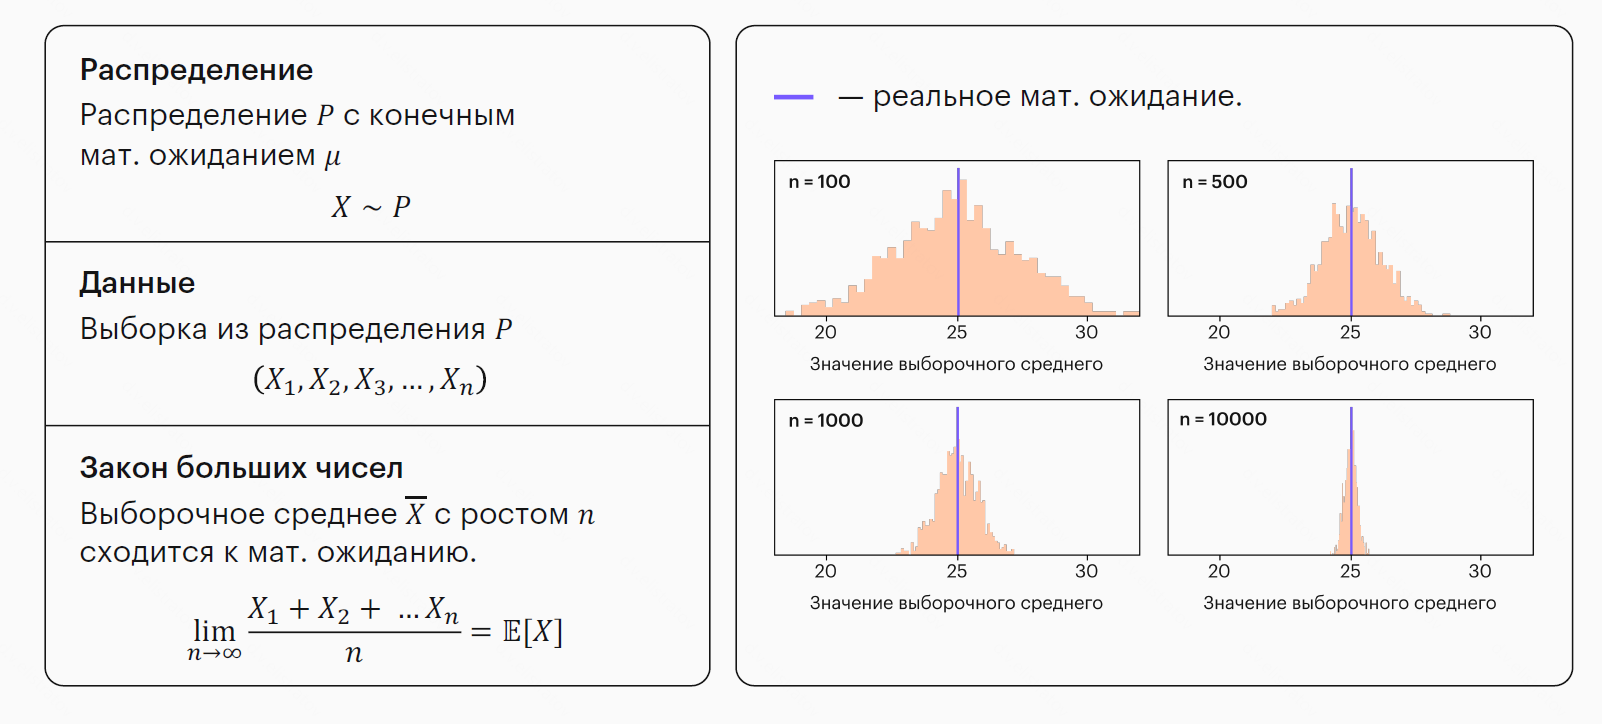

## Пример. Симуляция броска игрального кубика

Возьмем игральный кубик. Известно, что результаты подбрасывания распределены равномерно, с математическим ожиданием $3.5$

Давайте подбросим кубик $1000$ раз и после каждого нового подбрасывания будем пересчитывать среднее значение результатов.

Покажем, что чем больше подбрасываний мы совершаем, тем ближе мы сходимся к *истинному математическому ожиданию*.


In [ ]:
n_trial = 1000  ### Количество подбрасываний

cube = np.arange(1, 7) ### Вектор потенциальных исходов
print(type(cube))
print(cube)

<class 'numpy.ndarray'>
[1 2 3 4 5 6]


В векторе $X$ будем хранить результаты подбрасывания кубика

In [ ]:
x = np.random.choice(cube, size=n_trial)
print('Итоги подбрасывания кубика')
x[:50]
print(len(x))

Итоги подбрасывания кубика
1000


Рассчитаем вектор кумулятивных средних

In [ ]:
x_cumsum = np.cumsum(x)
x_mean = x_cumsum / np.arange(1, n_trial+1)

print('Изменение среднего значения при увеличении числа подбрасываний')
x_mean[:50]

Изменение среднего значения при увеличении числа подбрасываний


array([6.        , 6.        , 5.        , 4.25      , 3.8       ,
       3.33333333, 3.71428571, 4.        , 4.        , 3.9       ,
       4.09090909, 3.83333333, 4.        , 3.85714286, 4.        ,
       4.        , 3.94117647, 3.77777778, 3.68421053, 3.7       ,
       3.71428571, 3.81818182, 3.69565217, 3.625     , 3.64      ,
       3.69230769, 3.62962963, 3.57142857, 3.5862069 , 3.6       ,
       3.67741935, 3.59375   , 3.66666667, 3.61764706, 3.6       ,
       3.52777778, 3.51351351, 3.47368421, 3.53846154, 3.6       ,
       3.6097561 , 3.57142857, 3.60465116, 3.54545455, 3.57777778,
       3.63043478, 3.68085106, 3.66666667, 3.6122449 , 3.64      ])

Вспомним, что

$$P\left\{\left| \frac{X_1 + \dotsc + X_n}{n} - \mathbb{E}(X) \right| \ge \varepsilon\right\} \to 0, \text{при } n\to  \infty \text{ и } \varepsilon > 0$$

In [ ]:
### Зададим произвольный эпсилон
eps = 0.1

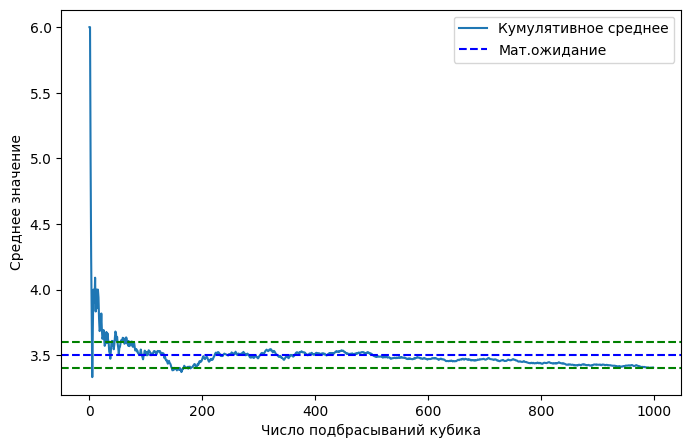

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x_mean, label = 'Кумулятивное среднее')
plt.axhline(3.5 + eps, color='g', lw=1.5, ls='--')
plt.axhline(3.5 - eps, color='g', lw=1.5, ls='--')
plt.axhline(3.5, color='b', lw=1.5, ls='--', label = 'Мат.ожидание')
plt.xlabel('Число подбрасываний кубика')
plt.ylabel('Среднее значение')
plt.legend()
plt.show()

**Вывод**

Как и ожидалось, чем больше подбрасываний ("экспериментов"), тем ближе среднее к математическому ожиданию.


Теперь нарисуем график следующей вероятности:

$$P\left\{\left| \overline{X} - 3.5 \right| \ge \varepsilon\right\} \to 0$$

По сути с помощью $\varepsilon>0$ можно задать некий "коридор", в нашем случае это $3.5\pm \varepsilon$,  и увидеть как с ростом числа ноблюдений $\bar{x}$ попадет в этот "коридор" и все реже будет выбиваться из него.

- Проведем $1000$ подбрасываний
- Проведём $10000$ итераций и в каждом проведём $1000$ побрасываний.

Возьмем значения $\varepsilon=0.1$ и $\varepsilon=0.01$

In [ ]:
eps1 = .1
eps2 = .01

n_trial = 10000  ### Количество подбрасываний
n_iter = 1000  ### Количество итераций

avg_true = 3.5

cube = np.arange(1, 7)

x = np.random.choice(cube, size=(n_trial, n_iter))
print(x[:3])

[[1 4 2 ... 5 6 4]
 [3 2 3 ... 5 5 5]
 [6 2 4 ... 3 1 3]]


Произведём расчёт кумулятивного среднего *в рамках каждой итерации*.



In [ ]:
x_cumsum = np.cumsum(x, axis=0)  # почситали кумулятивную сумму
x_mean = x_cumsum / np.arange(1, n_trial+1)[:, None]  # каждое значение поделили на n на отрезке [1, ..., 100]

print('Средние')
print(x_mean[:3])

Средние
[[1.         4.         2.         ... 5.         6.         4.        ]
 [2.         3.         2.5        ... 5.         5.5        4.5       ]
 [3.33333333 2.66666667 3.         ... 4.33333333 4.         4.        ]]


In [ ]:
# для каждого среднего ставим флаг True (1), если он выпал за коридор, иначе False(0)
bad_means1 = np.abs(x_mean - avg_true) > eps1
bad_means2 = np.abs(x_mean - avg_true) > eps2

print(bad_means1[:3])
print(bad_means2[:3])

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


Вероятнось выпать из "коридора" - это доля таких средних, которые выпали из $1000$ экспериментов при $n$.

In [ ]:
prob1 = np.mean(bad_means1, axis=1)
prob2 = np.mean(bad_means2, axis=1)
print(prob1[:5])
print(prob2[:5])

[1.    0.845 1.    0.856 1.   ]
[1.    0.845 1.    0.856 1.   ]


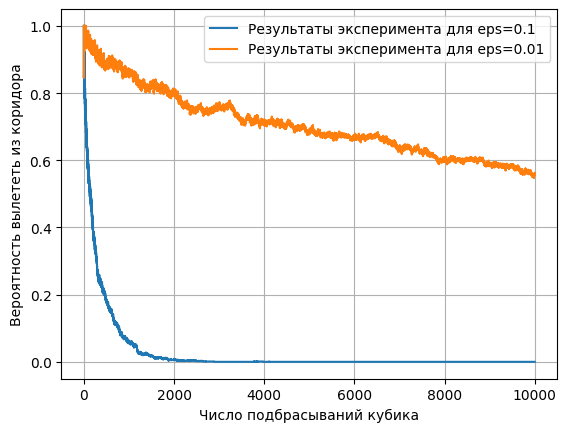

In [ ]:
plt.plot(prob1, label = 'Результаты эксперимента для eps=0.1')
plt.plot(prob2, label = 'Результаты эксперимента для eps=0.01')
plt.xlabel('Число подбрасываний кубика')
plt.ylabel('Вероятность вылететь из коридора')
plt.legend()
plt.grid()
plt.show()

Видно что сначала вероятность выпасть их коридора является высокой, но постепенно падает и выходит на плато. При этом для более узкого коридора вероятность убывает медленее, но все равно убывает.

**Мы продемонстрировали закон больших чисел**

## Контрпример. Распределение Коши

Случайная величина $X$ имеет **распределение Коши** с параметрами сдвига $x_0 \in \mathbb{R}$ и масштаба $\gamma > 0$, если её функция плотности вероятности задаётся формулой:

$$
f(x; x_0, \gamma) = \frac{1}{\pi \gamma \left[1 + \left(\frac{x - x_0}{\gamma}\right)^2\right]}
$$

Обозначают $X \sim \mathrm{Cauchy}(x_0, \gamma)$.

**Распределение Коши не имеет конечного математического ожидания и дисперсии.**

Математическое ожидание определяется как интеграл:
$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot f(x; x_0, \gamma) \, dx$$

Рассмотрим данный интеграл для стандартного распределения Коши ($x_0=0, \gamma=1$):

$$\mathbb{E}[X] = \frac{1}{\pi} \int_{-\infty}^{\infty} \frac{x}{1+x^2} \, dx$$

Это несобственный интеграл, который расходится, так как подынтегральная функция ведёт себя как $1/x$ на бесконечности.

Аналогично, второй момент (и дисперсия) также бесконечны:
$$\mathbb{E}[X^2] = \frac{1}{\pi} \int_{-\infty}^{\infty} \frac{x^2}{1+x^2} \, dx = \frac{1}{\pi} \int_{-\infty}^{\infty} \left(1 - \frac{1}{1+x^2}\right) dx = \frac{1}{\pi} \left[ \int_{-\infty}^{\infty} dx - \int_{-\infty}^{\infty} \frac{1}{1+x^2} dx \right].$$

Первый интеграл расходится, следовательно, дисперсия не определена.


Сгенерировать распределение можно с помощью `stats.cauchy()`


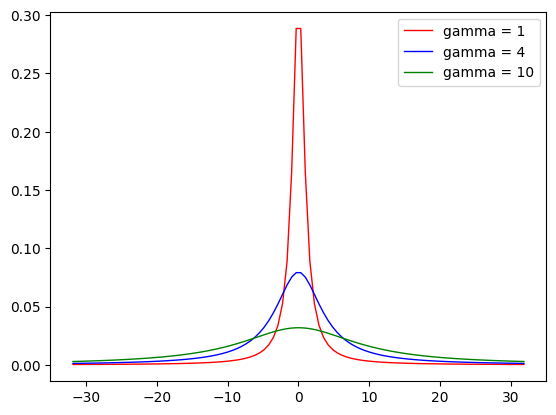

In [ ]:
from scipy.stats import cauchy

gamma1 = 1
gamma2 = 4
gamma3 = 10

fig, ax = plt.subplots(1, 1)
x = np.linspace(cauchy.ppf(0.01, loc = 0, scale = gamma1),
                cauchy.ppf(0.99, loc = 0, scale = gamma1), 100)
ax.plot(x, cauchy.pdf(x, loc = 0, scale = gamma1), color = 'red', lw=1, label='gamma = 1')
ax.plot(x, cauchy.pdf(x, loc = 0, scale = gamma2), color = 'blue', lw=1, label='gamma = 4')
ax.plot(x, cauchy.pdf(x, loc = 0, scale = gamma3), color = 'green', lw=1, label='gamma = 10')
plt.legend(loc = 'upper right')
plt.show()

**Таким образом, Закон Больших Чисел не работает**

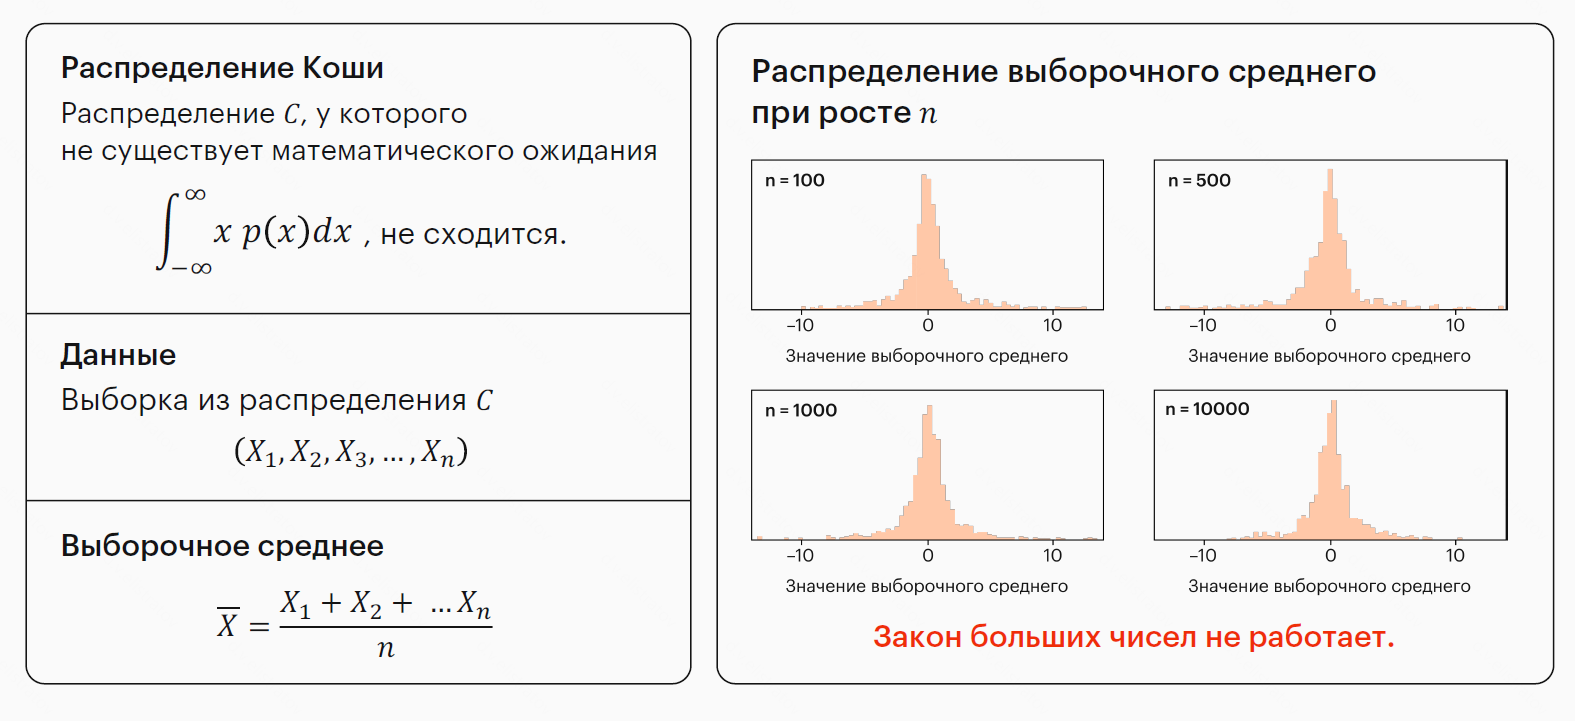

Теперь покажем отсутствие сходимости вероятности "вылететь из эпсилон-коридора" к нулю для распределения Коши.

In [ ]:
n_exp = 1000
n_trial = 10**4
cauchy_rv = cauchy()
x = cauchy_rv.rvs(size=(n_trial, n_exp))

In [ ]:
x_cumsum = np.cumsum(x, axis=0)
x_mean = x_cumsum / np.arange(1, n_trial+1)[:, None]

In [ ]:
eps1 = 0.1
eps2 = 0.01

bad_means1 = np.abs(x_mean - 0) > eps1
bad_means2 = np.abs(x_mean - 0) > eps2

prob1 = np.mean(bad_means1, axis=1)
prob2 = np.mean(bad_means2, axis=1)

exp_1 = x_mean[:, 2]
exp_2 = x_mean[:, 12]

<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-3460089873.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Результаты эксперимента для $\epsilon$={exp[1]}')


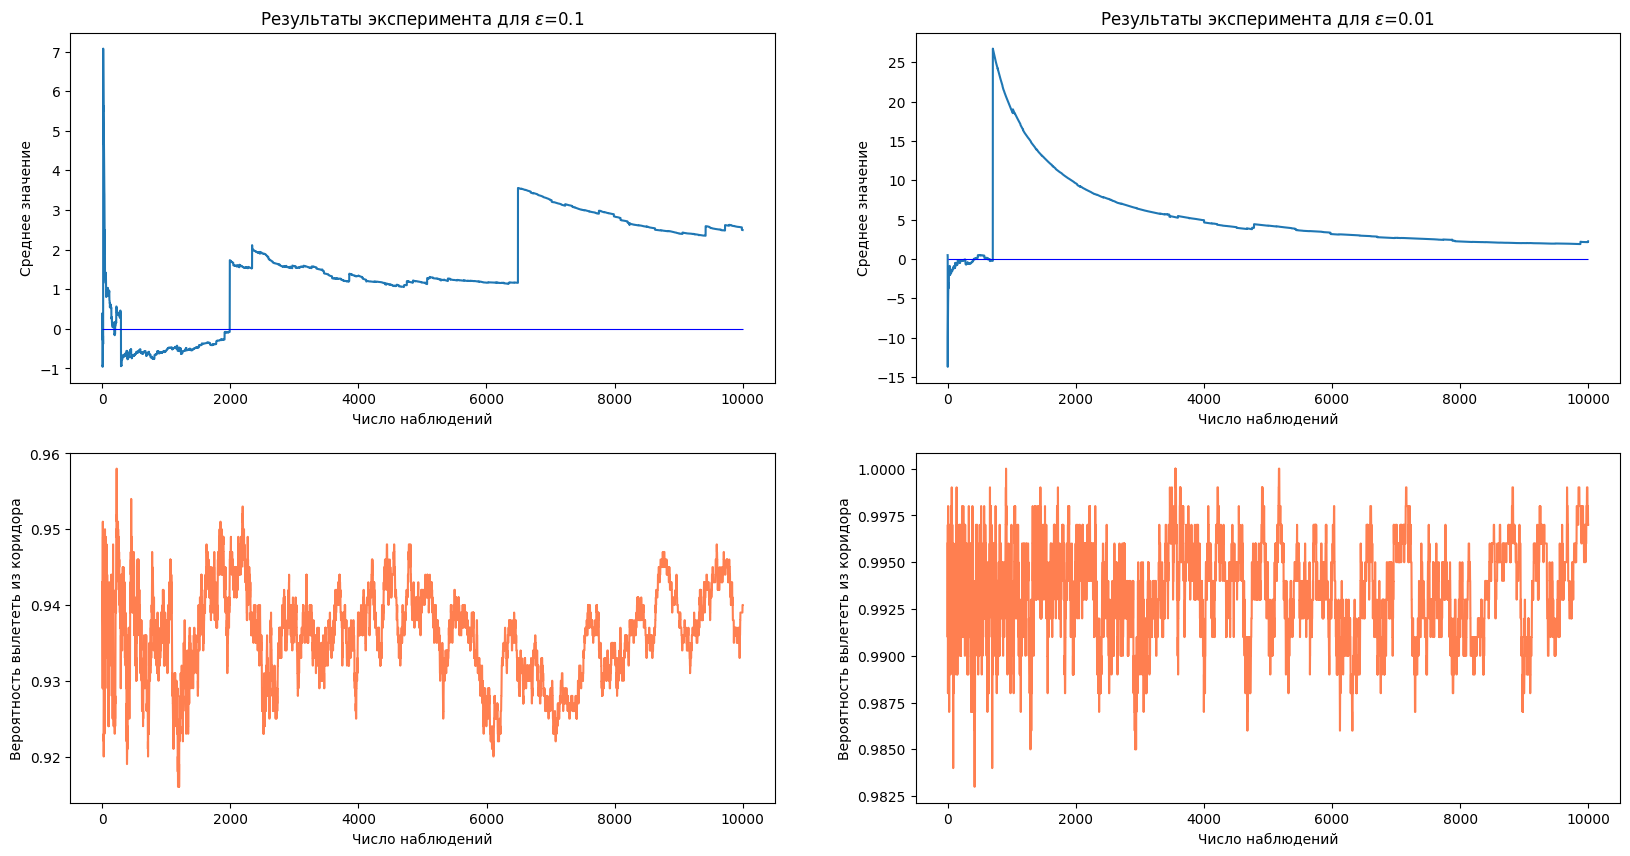

In [ ]:
zip_data = zip([exp_1, exp_2], [eps1, eps2], [prob1, prob2])

plt.figure(figsize=(20, 10))
for i, exp in enumerate(zip_data):
  plt.subplot(2,2, i+1)
  plt.plot(exp[0])
  plt.hlines(0, 0, n_trial, colors='b', lw=0.8, ls='-')
  plt.title(f'Результаты эксперимента для $\epsilon$={exp[1]}')
  plt.xlabel('Число наблюдений')
  plt.ylabel('Среднее значение')
  plt.subplot(2,2, i+3)
  plt.plot(exp[2], color='coral')
  plt.xlabel('Число наблюдений')
  plt.ylabel('Вероятность вылететь из коридора')
plt.show()

**Вывод:**

Следствие Закона Больших Чисел неприменим к распределению Коши.

# Задача 2. Произвольная случайная величина и ЦПТ

Пусть $X_1,X_2,\dots,X_n$ независимы и одинаково распределены. Распределение одной случайной величины $X$ задано таблицей.

| $x$ | $10$ | $6.67$ | $-13$ |
|---:|---:|---:|---:|
| $\mathbb{P}(X=x)$ | $0.63$ | $0.07$ | $0.30$ |

Нужно найти:

1. $\mathbb{E}\left(\sum\limits_{i=1}^{n} X_i\right)$;
2. $\operatorname{Var}\left(\sum\limits_{i=1}^{n} X_i\right)$;
3. $\mathbb{E}(\bar X)$;
4. $\operatorname{Var}(\bar X)$;
5. приблизительное распределение $\bar X$ при достаточно большом $n$;
6. приблизительное распределение $\sum\limits_{i=1}^{n}X_i$ при достаточно большом $n$;
7. приблизительное значение $\mathbb{P}(\bar X<2.87)$ при $n=200\,000$.

**Решение**



## Пункт 1. Матожидание суммы

Сначала найдём математическое ожидание одной случайной величины:

$$
\mathbb{E}(X)=10\cdot 0.63+6.67\cdot 0.07+(-13)\cdot 0.30=2.8669\approx 2.87.
$$

Тогда по линейности математического ожидания:

$$
\mathbb{E}\left(\sum\limits_{i=1}^{n}X_i\right)=\sum\limits_{i=1}^{n}\mathbb{E}(X_i)=n\mathbb{E}(X)\approx 2.87n.
$$

In [ ]:
df = pd.DataFrame({
    'x': [10, 6.67, -13],
    'p': [0.63, 0.07, 0.30],
})

ex = (df['x'] * df['p']).sum()
ex

np.float64(2.8669)

## Пункт 2. Дисперсия суммы

Найдём дисперсию одной случайной величины:

$$
\operatorname{Var}(X)=\mathbb{E}(X^2)-\left(\mathbb{E}(X)\right)^2.
$$

Для данной модели:

$$
\operatorname{Var}(X)\approx 108.5951\approx 108.6.
$$

Так как величины независимы:

$$
\operatorname{Var}\left(\sum\limits_{i=1}^{n}X_i\right)=\sum\limits_{i=1}^{n}\operatorname{Var}(X_i)=n\operatorname{Var}(X)\approx 108.6n.
$$

In [ ]:
ex2 = (df['x']**2 * df['p']).sum()
var_x = ex2 - ex**2
var_x

np.float64(108.59510739)

## Пункт 3. Матожидание среднего

Выборочное среднее равно:

$$
\bar X=\frac{1}{n}\sum\limits_{i=1}^{n}X_i.
$$

Тогда:

$$
\mathbb{E}(\bar X)=\mathbb{E}\left(\frac{1}{n}\sum\limits_{i=1}^{n}X_i\right)=\frac{1}{n}\cdot n\mathbb{E}(X)=\mathbb{E}(X)\approx 2.87.
$$

In [ ]:
ex_bar = ex
ex_bar

np.float64(2.8669)

## Пункт 4. Дисперсия среднего

Так как при умножении случайной величины на константу дисперсия умножается на квадрат этой константы:

$$
\operatorname{Var}(\bar X)=\operatorname{Var}\left(\frac{1}{n}\sum\limits_{i=1}^{n}X_i\right)=\frac{1}{n^2}\cdot n\operatorname{Var}(X)=\frac{\operatorname{Var}(X)}{n}.
$$

Значит:

$$
\operatorname{Var}(\bar X)\approx \frac{108.6}{n}.
$$

In [ ]:
# Например, при n = 200000:
n = 200000
var_bar = var_x / n
var_bar

np.float64(0.00054297553695)

## Пункт 5. Распределение среднего

По центральной предельной теореме при достаточно большом $n$:

$$
\bar X \approx N\left(\mathbb{E}(X),\frac{\operatorname{Var}(X)}{n}\right).
$$

В этой задаче:

$$
\bar X \approx N\left(2.8669,\frac{108.5951}{n}\right).
$$

In [ ]:
n = 200000
mean_bar = ex
std_bar = math.sqrt(var_x / n)
mean_bar, std_bar

(np.float64(2.8669), 0.023301835484570738)

## Пункт 6. Распределение суммы

Для суммы по центральной предельной теореме:

$$
\sum\limits_{i=1}^{n}X_i \approx N\left(n\mathbb{E}(X),n\operatorname{Var}(X)\right).
$$

В этой задаче:

$$
\sum\limits_{i=1}^{n}X_i \approx N\left(2.8669n,108.5951n\right).
$$

In [ ]:
n = 200000
sum_mean = n * ex
sum_std = math.sqrt(n * var_x)
sum_mean, sum_std

(np.float64(573380.0), 4660.367096914148)

## Пункт 7. Вероятность меньше

При $n=200\,000$:

$$
\bar X \approx N\left(2.8669,\frac{108.5951}{200\,000}\right).
$$

Поэтому:

$$
\mathbb{P}(\bar X<2.87)\approx 0.557.
$$

In [ ]:
n = 200000
prob = sps.norm.cdf(2.87, loc=ex, scale=math.sqrt(var_x / n))
prob

np.float64(0.5529178339063763)

# Задача 3. Симуляция Центральной Предельной Теоремы с помощью экспоненциального распределения


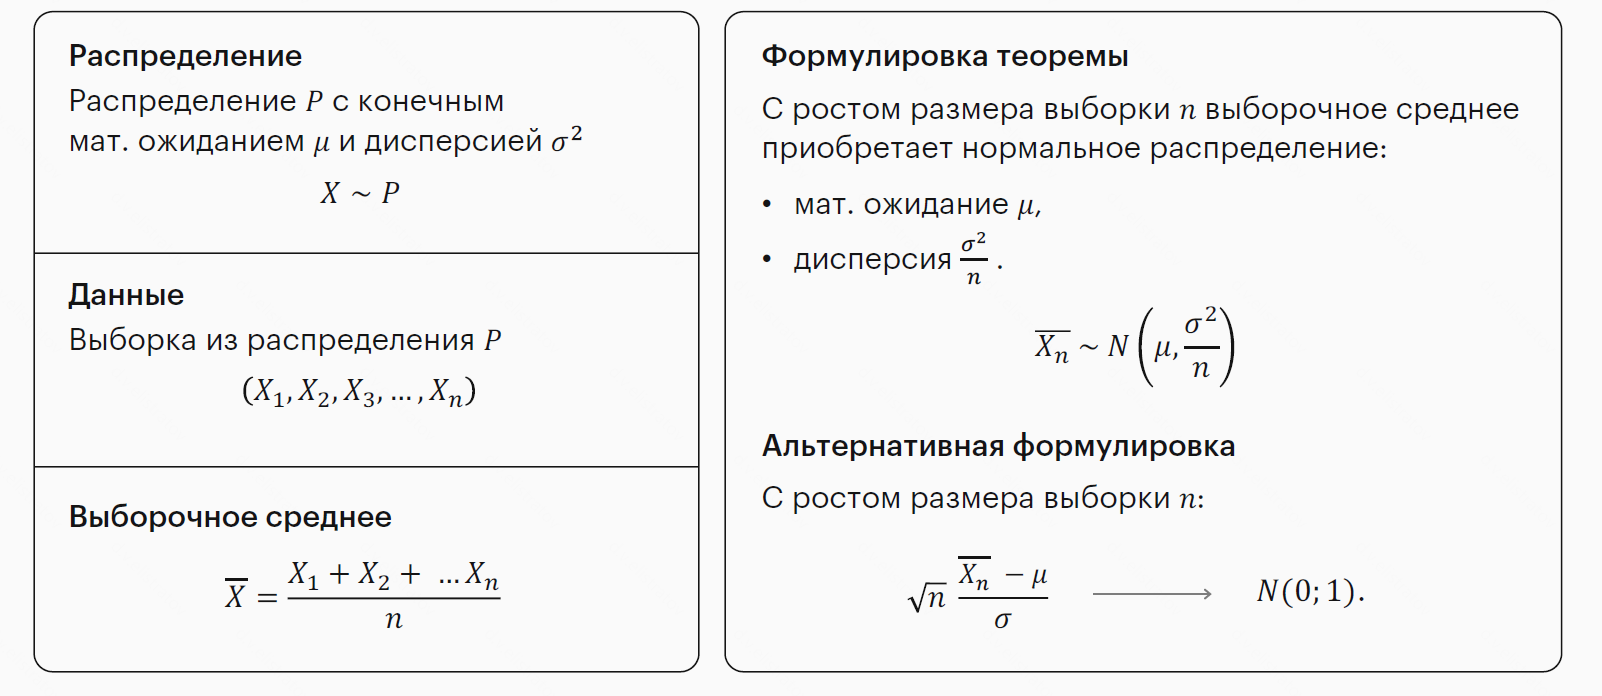

**Пример**

Теперь сгенерируем $N$ случайных величин по $M$ наблюдений и продемонстрируем, как среднее стремится к нормальному распределению.

In [ ]:
n_obs = 1000   # Количество наблюдений (размер выборки для гистограмм)

In [ ]:
n_values = [1, 10, 10000]

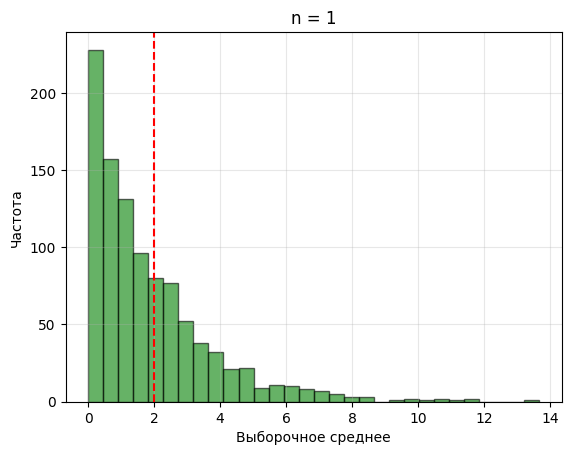

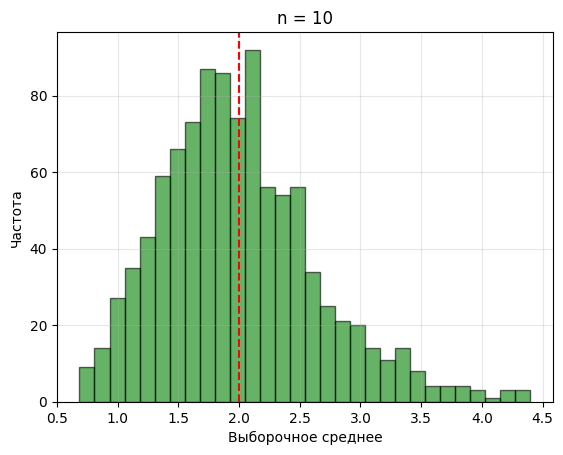

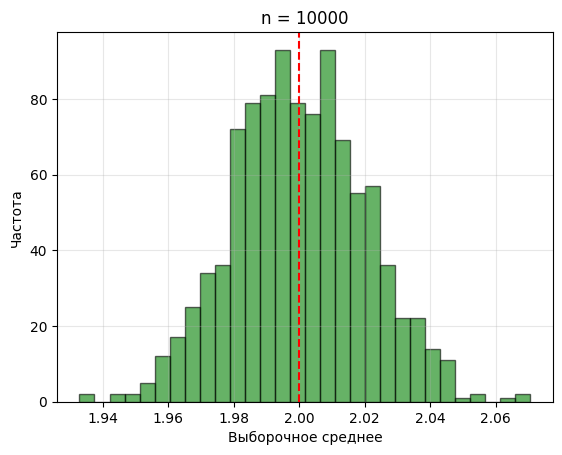

In [ ]:
for n in n_values:
    means = []
    for i in range(n_obs):
        samples = expon_rv.rvs(n)
        means.append(np.mean(samples))

    plt.figure()
    plt.hist(means, bins=30, color='green', alpha=0.6, edgecolor='black')
    plt.axvline(1 / lambda_param, color='red', linestyle='--')
    plt.title(f'n = {n}')
    plt.xlabel('Выборочное среднее')
    plt.ylabel('Частота')
    plt.grid(alpha=0.3)
    plt.show()

**Вывод:**

Чем больше выборок, тем ближе выборочное среднее к нормальному распределению.

# Задача 4. Вероятность не менее половины мальчиков и теорема Муавра-Лапласа

Найти вероятность того, что среди $20\,000$ новорождённых будет не менее половины мальчиков, если вероятность рождения мальчика составляет $0.515$.

Для решения воспользуйтесь теоремой Муавра-Лапласа.


**Решение**


Пусть $\xi$ — число мальчиков среди $20\,000$ новорождённых.

Тогда

$$
\xi\sim \operatorname{Bin}(20000,0.515)
$$

Здесь

$$
n=20000,\quad p=0.515,\quad q=0.485
$$

Математическое ожидание:

$$
np=20000\cdot 0.515=10300
$$

Дисперсия:

$$
npq=20000\cdot 0.515\cdot 0.485=4995.5
$$

Стандартное отклонение:

$$
\sqrt{npq}\approx 70.68
$$

Нужно найти

$$
\mathbb{P}(\xi\geq 10000)
$$

Стандартизируем:

$$
\frac{10000-10300}{70.68}\approx -4.24
$$

По интегральной теореме Муавра — Лапласа:

$$
\mathbb{P}(\xi\geq 10000)
\approx
1-\Phi(-4.24)
=
\Phi(4.24)
$$

Так как $\Phi(4.24)$ очень близко к $1$, получаем

$$
\mathbb{P}(\xi\geq 10000)\approx 0.99999
$$


# Задача 5. Демонстрация нарушения предпосылок ЦПТ

У вас есть данные покупки пользователей в разрезе их заказов.

Нашей основной метрикой выступает *gmv*, то есть выплаченная в заказе сумма.

Рассмотрим метрику "*Средняя цена на заказ*", она же **средний чек**. Назовём её *Average Order Value – AOV*.

Допустим, что нам известно, что **на самом деле** распределение **AOV**: она распределена нормально (как и положено среднему по ЦПТ) со средним значением **218.5** и дисперсией **0.533**.

С помощью множественного семплинга нарисуй эмпирическую гистограмму **AOV** и наложи её на *истинное* распределение **AOV**.

Как обосновать полученные результаты?



Начнём с создания переменных для **истинных** показателей распределения, а также визуализации **истинного** распределения **AOV**.

In [ ]:
aov_mean = 218.5
aov_var = 0.533
aov_std = np.sqrt(0.533)

In [ ]:
from scipy.stats import norm

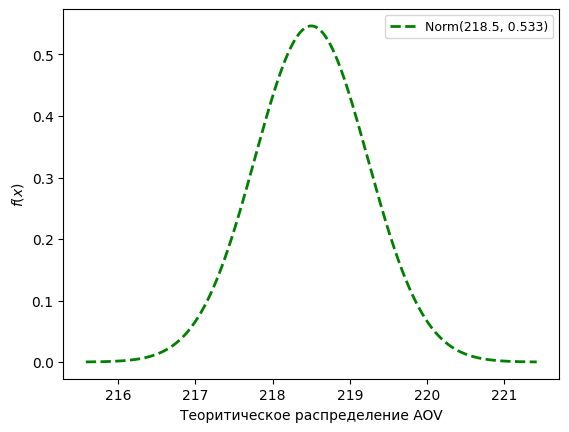

In [ ]:
x = np.linspace(aov_mean-4*aov_std, aov_mean+4*aov_std, 1000)
pdf = norm.pdf(x, loc=aov_mean, scale=aov_std)
plt.plot(x, pdf, color='green', ls='--', lw=2, label=f'Norm({round(aov_mean,2)}, {round(aov_std**2,3)})')
plt.ylabel(f'$f(x)$')
plt.xlabel(f'Теоритическое распределение AOV')
plt.legend(fontsize=9, loc=1)
plt.show()

Теперь импортируем **эмпирические** данные

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1IXvOMTrJdHprkJUEUIQsofMeyh0RDnm5', sep=',')
df.sort_values(by='user_id').head(10)

,user_id,order_id,gmv
71295,U_0000bfdc,O_4881100,400.0
49978,U_0000bfdc,O_8400354,290.0
52571,U_0000bfdc,O_1175861,70.0
94773,U_0000bfdc,O_8831732,180.0
93850,U_0000bfdc,O_4837651,470.0
85125,U_0000bfdc,O_8632180,120.0
53424,U_00012393,O_6624281,290.0
54070,U_00012393,O_3324628,360.0
5697,U_000404a3,O_8444863,200.0
7215,U_000404a3,O_0172273,320.0



* `user_id` - идентификатор пользователя
* `order_id` – идентификатор заказа
* `gmv` – цена заказа

Проверим значение среднего чека

In [ ]:
round(df.gmv.mean(), 2)

np.float64(218.5)

**Вывод**

Совпадает с теоретическим средним **AOV**.

А теперь нарисуем эмпирическую кривую распределения AOV, рассчитав показатели матожидания и дисперсии.

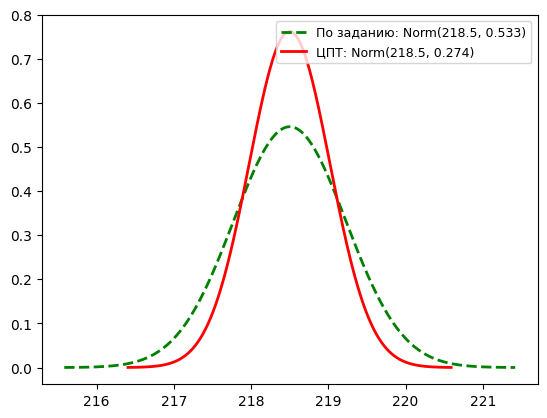

In [ ]:
# нарисуем нормальное распределение из прошлой ячейки
plt.plot(x, pdf, color='green', ls='--', lw=2, label=f'По заданию: Norm({round(aov_mean,2)}, {round(aov_std**2,3)})')

#ЦПТ
gmv_values = df.gmv.values
n = len(gmv_values)
smpl_mean = np.mean(gmv_values)
smpl_var = np.var(gmv_values)
smpl_std = np.sqrt(smpl_var)

# Приготовим распределение метрики согласно ЦПТ
norm_mean = smpl_mean
norm_std = smpl_std / np.sqrt(n)

x = np.linspace(norm_mean-4*norm_std, norm_mean+4*norm_std, 1000)
pdf2 = norm.pdf(x, loc=norm_mean, scale=norm_std)
plt.plot(x, pdf2, color='r', ls='-', lw=2, label=f'ЦПТ: Norm({round(norm_mean,2)}, {round(norm_std**2,3)})')
plt.legend(fontsize=9, loc=1)
plt.show()

**Вывод**

Видим, что кривые не совпадают!

**Но почему?**

Дело в том, что у нас нарушена предпосылка ЦПТ.

Сами по себе пользователи могут быть независимыими друг от друга, однако покупки в рамках одного пользователя **не являются независимыми** друг от друга.

Тогда перейдём на уровень пользователя, чтобы обеспечить независимость наблюдений.


In [ ]:
grouped_df = df.groupby('user_id', as_index=False).agg(
    n_order=('order_id', 'count'),
    gmv=('gmv', 'sum')
)

grouped_df.head() # одна строка – один пользователь

,user_id,n_order,gmv
0,U_0000bfdc,6,1530.0
1,U_00012393,2,650.0
2,U_000404a3,3,830.0
3,U_0007ac22,5,380.0
4,U_000e5aab,2,560.0


Создадим переменные


In [ ]:
n_order_values = grouped_df.n_order.values
gmv_values = grouped_df.gmv.values

Теперь насемплируем выборки

In [ ]:
empiric_aov = []

for _ in range(5000):

    # берем индексы пользователей с повторением
    random_users_idx = np.random.choice(np.arange(0, len(n_order_values)), size=len(n_order_values), replace=True)

    # находим их сигналы в исходных выборках
    tmp_order = n_order_values[random_users_idx]
    tmp_gmv = gmv_values[random_users_idx]

    # переходим к серднему
    tmp_aov = tmp_gmv.sum() / tmp_order.sum()

    # фиксируем среднее
    empiric_aov.append(tmp_aov)


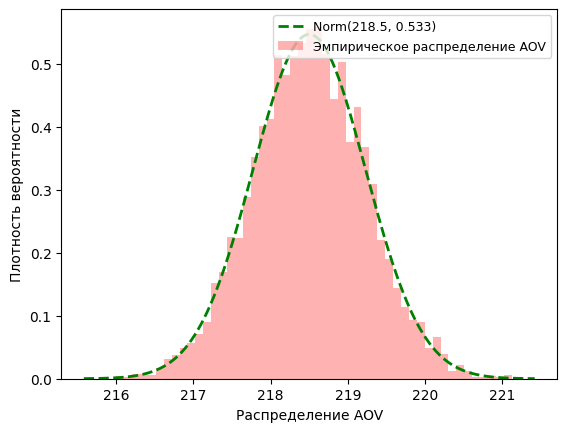

In [ ]:
x = np.linspace(aov_mean-4*aov_std, aov_mean+4*aov_std, 1000)
pdf = norm.pdf(x, loc=aov_mean, scale=aov_std)
plt.plot(x, pdf, color='green', ls='--', lw=2, label=f'Norm({round(aov_mean,2)}, {round(aov_std**2,3)})')

# а это уже новое насемплированное
plt.hist(empiric_aov, bins=50, density=True, color='red', alpha=0.3, label='Эмпирическое распределение AOV')
plt.xlabel('Распределение AOV')
plt.ylabel('Плотность вероятности')
plt.legend(fontsize=9, loc=1)
plt.show()

In [ ]:
emp_mean = round(np.mean(empiric_aov), 2)
emp_var = round(np.var(empiric_aov), 3)

print(f'Исходное значение AOV: {aov_mean}, исходная дисперсия AOV: {aov_var}')
print(f'Эмпирическое значение AOV: {emp_mean}, эмпирическая дисперсия AOV: {emp_var}')

Исходное значение AOV: 218.5, исходная дисперсия AOV: 0.533
Эмпирическое значение AOV: 218.5, эмпирическая дисперсия AOV: 0.535


# Задача 6. Симуляция теоремы о нормальности выборочной квантили с помощью экспоненциального распределения

**Задача**

 1. Создай выборку из экспоненциального распределения с параметром $\lambda=0.5$ размера $300$
 2. Построй гистограмму распеделения и отметь на ней вертикальными линиями разных цветов:
  - Матожидание;
  - Выборочное среднее;
  - Первый и третий квартиль;
  - Первый и девятый дециль;
  - Матожидание плюс три сигмы;
  - Матожидание минус три сигмы;

In [ ]:
from scipy.stats import expon

In [ ]:
lambda_param = 0.5

expon_rv = expon(scale=1/lambda_param)

In [ ]:
print(expon_rv)
print(type(expon_rv))

<class 'scipy.stats._distn_infrastructure.rv_continuous_frozen'>


In [ ]:
data = expon_rv.rvs(n)

print(data[:10])
print(len(data))

[0.09865798 5.87220124 1.52857048 0.04282173 0.28026528 9.6993031
 3.73735454 3.47206715 1.18676667 2.44025715]
300


In [ ]:
mean_sample = np.mean(data)   # выборочное среднее
mean_theor = 1 / lambda_param # матожидание (теоретическое)
q1 = np.percentile(data, 25)  # первый квартиль (25%)
q3 = np.percentile(data, 75)  # третий квартиль (75%)
d1 = np.percentile(data, 10)  # первый дециль (10%)
d9 = np.percentile(data, 90)  # девятый дециль (90%)

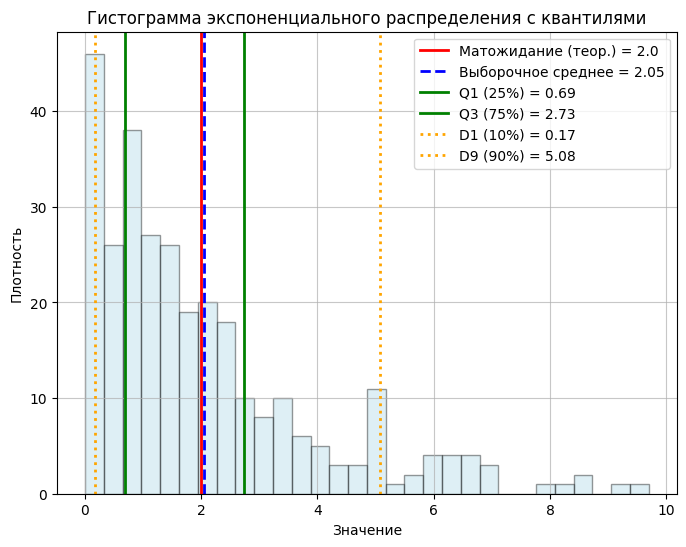

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data, bins=30, alpha=0.4, color='lightblue', edgecolor='black')

# Добавляем вертикальные линии
plt.axvline(mean_theor, color='red', linewidth=2, label=f'Матожидание (теор.) = {mean_theor}')
plt.axvline(mean_sample, color='blue', linewidth=2, linestyle='--', label=f'Выборочное среднее = {mean_sample:.2f}')
plt.axvline(q1, color='green', linewidth=2, label=f'Q1 (25%) = {q1:.2f}')
plt.axvline(q3, color='green', linewidth=2, label=f'Q3 (75%) = {q3:.2f}')
plt.axvline(d1, color='orange', linewidth=2, linestyle=':', label=f'D1 (10%) = {d1:.2f}')
plt.axvline(d9, color='orange', linewidth=2, linestyle=':', label=f'D9 (90%) = {d9:.2f}')

# Оформление
plt.title('Гистограмма экспоненциального распределения с квантилями')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.7)
plt.show()

Параметры эксперимента

In [ ]:
sample_size = 1000         # размер одной выборки
num_samples = 10000       # сколько выборок берем
p = 0.3                   # какой квантиль считаем (30-й процентиль)

Вычисляем истинный квантиль генеральной совокупности

In [ ]:
true_quantile = expon_rv.ppf(p)

print(true_quantile)

0.7133498878774649


Берем *num_samples* выборок размера *sample_size* из экспоненциального распределения и для каждой считаем выборочный квантиль

In [ ]:
sample_quantiles = []
for _ in range(num_samples):
    sample = expon_rv.rvs(sample_size)
    q = np.quantile(sample, p)
    sample_quantiles.append(q)

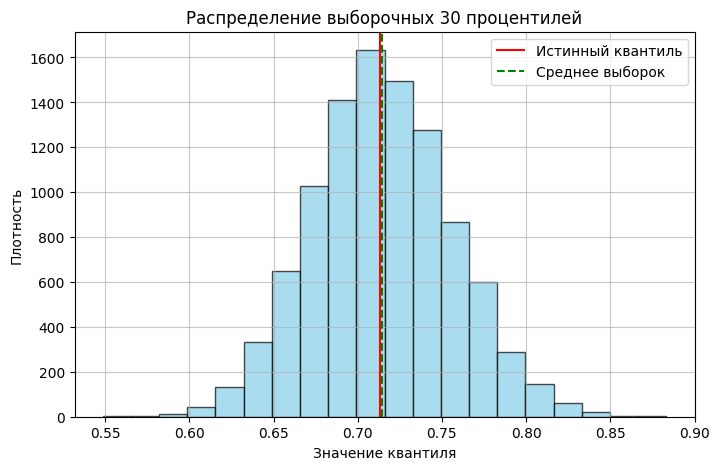

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(sample_quantiles, bins = 20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(true_quantile, color='red', label='Истинный квантиль')
plt.axvline(np.mean(sample_quantiles), color='green',linestyle='--', label='Среднее выборок')
plt.title('Распределение выборочных 30 процентилей')
plt.xlabel('Значение квантиля')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.7)
plt.show()

# Задача 7. Точность оценки времени загрузки страниц и ЦПТ

Компания-разработчик веб-приложений хочет улучшить пользовательский опыт на своём сайте, измеряя время загрузки страниц. Пусть $X_1,X_2,\dots,X_n$ — независимые одинаково распределённые случайные величины, которые показывают время загрузки страницы в секундах.

Для упрощения считаем, что:

- выборка достаточно велика для применения ЦПТ;
- наблюдения независимы и одинаково распределены;
- стандартное отклонение $\sqrt{\operatorname{Var}(X)}$ не превосходит $15$ секунд.

Нужно найти:

1. $\mathbb{P}(|\bar X-\mathbb{E}X|\leq 0.5)$ при $n=1000$;
2. $\mathbb{P}(|\bar X-\mathbb{E}X|\leq 1)$ при $n=1000$;
3. минимальное $n$, чтобы точность $\pm 1$ секунда достигалась с вероятностью не меньше $99.9\%$;
4. минимальное $n$, чтобы точность $\pm 0.5$ секунды достигалась с вероятностью не меньше $99.9\%$;
5. какие изменения уменьшили бы необходимый размер выборки.

**Решение**



## Пункт 1. Отклонение на $0.5$

По ЦПТ:

$$
\bar X\approx N\left(\mathbb{E}X,\frac{\operatorname{Var}(X)}{n}\right).
$$

Тогда:

$$
\bar X-\mathbb{E}X\approx N\left(0,\frac{\operatorname{Var}(X)}{n}\right).
$$

В худшем случае берём стандартное отклонение $X$, равное $15$. При $n=1000$:

$$
\mathbb{P}(|\bar X-\mathbb{E}X|\leq 0.5)\approx 0.708.
$$

In [ ]:
n = 1000
std_x = 15
eps = 0.5
std_bar = std_x / math.sqrt(n)

prob = sps.norm.cdf(eps, loc=0, scale=std_bar) - sps.norm.cdf(-eps, loc=0, scale=std_bar)
prob

np.float64(0.7081594548562116)

## Пункт 2. Отклонение на $1$

Аналогично:

$$
\mathbb{P}(|\bar X-\mathbb{E}X|\leq 1)\approx 0.965.
$$

In [ ]:
n = 1000
std_x = 15
eps = 1
std_bar = std_x / math.sqrt(n)

prob = sps.norm.cdf(eps, loc=0, scale=std_bar) - sps.norm.cdf(-eps, loc=0, scale=std_bar)
prob

np.float64(0.9649850189803375)

## Пункт 3. Минимальное количество наблюдений для $1$

Нужно, чтобы:

$$
\mathbb{P}(|\bar X-\mathbb{E}X|\leq 1)\geq 0.999.
$$

Для центрального интервала вероятности $0.999$ нужен квантиль:

$$
z_{0.9995}\approx 3.2905.
$$

Поэтому:

$$
\frac{1}{15/\sqrt n}\geq z_{0.9995}.
$$

Отсюда:

$$
n\geq \left(\frac{15z_{0.9995}}{1}\right)^2.
$$

Минимальное целое значение:

$$
n=2437.
$$

In [ ]:
std_x = 15
eps = 1
z = sps.norm.ppf((1 + 0.999) / 2)
n_min = math.ceil((z * std_x / eps) ** 2)
n_min

2437

## Пункт 4. Минимальное количество наблюдений для $0.5$

Теперь точность в два раза выше: $\pm 0.5$ секунды. Тогда:

$$
n\geq \left(\frac{15z_{0.9995}}{0.5}\right)^2.
$$

Минимальное целое значение:

$$
n=9745.
$$

In [ ]:
std_x = 15
eps = 0.5
z = sps.norm.ppf((1 + 0.999) / 2)
n_min = math.ceil((z * std_x / eps) ** 2)
n_min

9745

## Пункт 5. Условия снижения размера выборки

Необходимый размер выборки уменьшается, если:

- допустимая погрешность становится больше, например вместо $\pm 0.5$ секунды достаточно $\pm 1$ секунды;
- требуемая вероятность становится меньше, например $99\%$ вместо $99.9\%$;
- разброс времени загрузки страниц становится меньше, то есть уменьшается $\sqrt{\operatorname{Var}(X)}$.

In [ ]:
std_x = 10
eps = 1
confidence = 0.99
z = sps.norm.ppf((1 + confidence) / 2)
n_min = math.ceil((z * std_x / eps) ** 2)
n_min

664

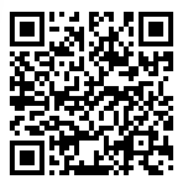